In [45]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import HMC, MCMC, MixedHMC, NUTS
import numpy as np
from scipy.stats import bernoulli, multivariate_normal, pearsonr, norm, multivariate_t
from sklearn import feature_selection, preprocessing,linear_model
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing  import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import train_test_split
from scipy.special import logit

from FairReg.FairReg import FairReg
from FairReg.evaluation_measures import DP_unfairness

from metrics import *
from preprocessing import get_communities_data
from utils import get_frequencies, plot_distributions_compare
from projection import evaluate_posterior_per_budget, evaluate_conjugate_posterior, sample_projection_posterior, sample_posterior_with_projection_prior
from methods import evaluate_calders, evaluate_frrm, standardlasso, fairlasso
from scipy.stats import gaussian_kde

In [46]:
random_seed = 0

## Data pre-processing

In [47]:
# load data
X,S,y = get_communities_data()

In [48]:
# data characteristics
print(X.shape, S.shape, y.shape)
print("Number of neighborhoods : ", y.shape[0])
print("Number of features : ", X.shape[1])
print("Avg crime rate : ", np.mean(y))
print("Percentage of white neighborhood : ", np.mean(S))

(1984, 118) (1984,) (1984,)
Number of neighborhoods :  1984
Number of features :  118
Avg crime rate :  0.23917842741935483
Percentage of white neighborhood :  0.7872983870967742


In [49]:
# check no missing value
np.isnan(X).sum()

0

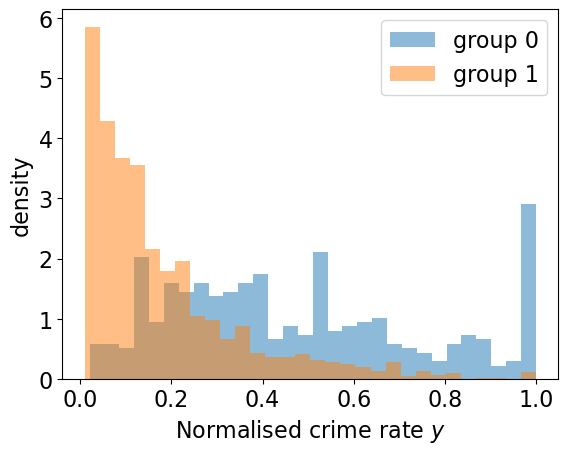

In [50]:
plt.rcParams.update({'font.size': 16})
# outcome distribution
plt.hist(y[S==0], alpha=0.5, density=True, label="group 0", bins=30)
plt.hist(y[S==1], alpha=0.5, density=True, label="group 1", bins=30)
plt.xlabel(r"Normalised crime rate $y$")
plt.ylabel(r"density")
plt.legend()
#plt.title("Outcome (normalised crime rate) distribution per group")
plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data.pdf")

In [51]:
# remove 1.0 and 0.0 outcome
inliers = (0.01 <= y) & (y <= 0.99)
y, X, S = y[inliers], X[inliers], S[inliers]

In [52]:
# eps = 0.005
# y = np.clip(y, eps, 1-eps)
# np.sum(y == 1.0)

In [53]:
# train test split
X_train, X_test, S_train, S_test, y_train, y_test = train_test_split(X, S, y, test_size=0.2, stratify=S, random_state=random_seed)
print(X_train.shape), print(X_test.shape)

(1552, 118)
(388, 118)


(None, None)

In [54]:
# apply preprocessing for output
y_train, y_test = logit(y_train), logit(y_test)
ym = np.mean(y_train)
y_train = y_train - ym
y_test = y_test - ym
# scaler = MinMaxScaler(feature_range=(-1, 1))
# y_scaled = scaler.fit_transform(y.reshape(-1, 1))
# y = y_scaled
#y = pd.Series(y_scaled.flatten(), index=y.index)
np.mean(y_train), np.mean(y_test)

(1.602383746881669e-17, -0.026373381608830224)

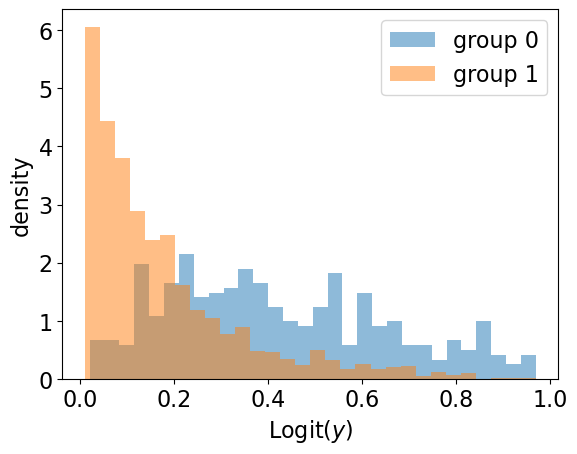

In [55]:
# outcome distribution after preprocessing
#plt.hist(y, alpha=0.5, density=True, bins=30)
fig, ax = plt.subplots()
ax.hist(y[S==0], alpha=0.5, density=True, label="group 0", bins=30)
ax.hist(y[S==1], alpha=0.5, density=True, label="group 1", bins=30)
plt.legend()
plt.xlabel(r"Logit$(y)$")
plt.ylabel(r"density")
#plt.title("Outcome distribution (after preprocessing) per group")
plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_preproc.pdf")

In [56]:
# standardise features
scalerX = StandardScaler()
X_train = scalerX.fit_transform(X_train)
X_test = scalerX.transform(X_test)
np.max(np.abs(np.mean(X_train, axis=0))), np.max(np.std(X_train, axis=0)), np.max(np.abs(np.mean(X_test, axis=0))), np.max(np.std(X_test, axis=0))

(2.870942315495571e-14,
 1.0000000000000142,
 0.13151074684482647,
 1.421605613241393)

In [57]:
# group frequencies
#get_frequencies(S)

In [58]:
# ranked correlation btw features and outcome
np.sort(np.abs(feature_selection.r_regression(X, y)))[::-1]

array([0.716921  , 0.70460287, 0.68213717, 0.64005764, 0.63103386,
       0.56832651, 0.55741268, 0.54361995, 0.53599147, 0.5160696 ,
       0.5034933 , 0.50217897, 0.47981355, 0.47830224, 0.46896935,
       0.45745852, 0.45729966, 0.43851161, 0.43757494, 0.43629634,
       0.4360075 , 0.42213692, 0.42175879, 0.40275626, 0.40165585,
       0.39804957, 0.39348253, 0.36043861, 0.35672768, 0.35410838,
       0.35366199, 0.35254727, 0.34988112, 0.34885079, 0.34793517,
       0.3477429 , 0.34470049, 0.34195452, 0.34035703, 0.3390418 ,
       0.33844794, 0.33289054, 0.3281907 , 0.3187853 , 0.31788654,
       0.31546842, 0.31505029, 0.30978348, 0.30967905, 0.30333263,
       0.30157028, 0.30126494, 0.29765209, 0.29635063, 0.2948125 ,
       0.29345005, 0.29319645, 0.29241524, 0.29136962, 0.28653703,
       0.28504674, 0.28146837, 0.28027724, 0.27983986, 0.27900701,
       0.27657531, 0.27073648, 0.25661092, 0.25208032, 0.25207698,
       0.24773733, 0.24747175, 0.24237439, 0.24080075, 0.24051

In [59]:
# correlation btw S and outcome
corr_y = feature_selection.r_regression(y.reshape(-1,1),S)
corr_y

array([-0.47935851])

In [60]:
# unfairness of outcome and of each feature
# corr = feature_selection.r_regression(X,S)
print("Measure of DP unfairness: TV, WD, MD and corr")
tvy, wdy, mdy = DP_unfairness_TV(y, S, bins=20), DP_unfairness_WD(y, S), mean_distance(y, S)
print(f"Outcome : {tvy:.3f}, {wdy:.3f}, {mdy:.3f}, {corr_y[0]:.3f}")
# for i in range(X.shape[1]):
#     tvx, wdx, mdx = DP_unfairness_TV(X[:,i], S, bins=20), DP_unfairness_WD(X[:,i], S), mean_distance(X[:,i], S)
#     print(f"Feature {i} : {tvx:.3f},  {wdx:.3f},  {mdx:.3f},  {corr[i]:.3f}")

Measure of DP unfairness: TV, WD, MD and corr
Outcome : 0.496, 0.247, 0.247, -0.479


In [61]:
# condition number of covariance
# np.linalg.det(X_train.transpose() @ X_train)

In [62]:
#Cov = X_train.transpose() @ X_train

In [63]:
# from sklearn.utils.extmath import row_norms
# np.sqrt(row_norms(X_train.transpose(), squared=True) - X_train.shape[0] * np.mean(X_train, axis=0) ** 2 )

## Inference

### Standard Lasso

In [64]:
X1_train = np.concatenate([np.ones(len(S_train)).reshape(-1,1), X_train], axis=1)
X1_test = np.concatenate([np.ones(len(S_test)).reshape(-1,1), X_test], axis=1)
XS_train = np.concatenate([S_train.reshape(-1,1), X_train], axis=1)
XS_test = np.concatenate([S_test.reshape(-1,1), X_test], axis=1)

In [65]:
alphas  = np.logspace(-5, 0, num=100, endpoint=True, base=10.0)
lasso = standardlasso()
lasso_results_train, lasso_results_val = lasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas, plot=False, coeff=2.,
                                                        metric="correlation", task="reg")

/Users/deborah/miniconda3/envs/fairness/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.191e+02, tolerance: 2.945e-01
  model = cd_fast.enet_coordinate_descent(
/Users/deborah/miniconda3/envs/fairness/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.012e+02, tolerance: 2.945e-01
  model = cd_fast.enet_coordinate_descent(
/Users/deborah/miniconda3/envs/fairness/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the fe

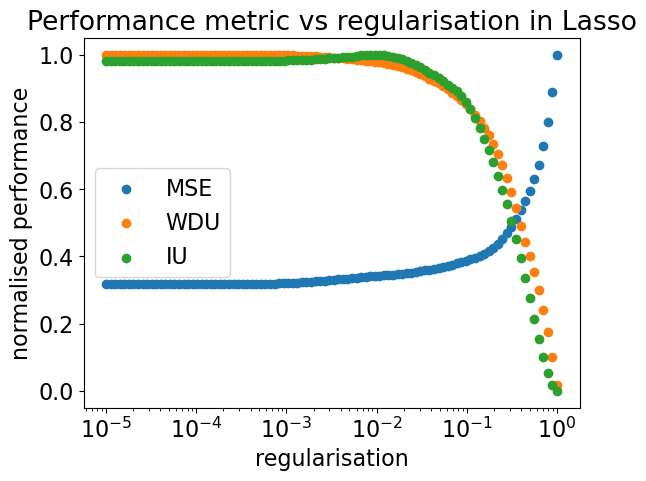

In [66]:
for m in ["MSE", "WDU", "IU"]:
    plt.scatter(lasso_results_train["alphas"], lasso_results_train[m] / max(lasso_results_train[m]), label=m)
#plt.scatter(lasso_results_train["alphas"], lasso_results_train["Correlation"] / max(lasso_results_train["Correlation"]), label="Correlation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
#plt.yscale("log")
plt.title("Performance metric vs regularisation in Lasso")
plt.xlabel("regularisation")
plt.ylabel("normalised performance")
plt.xscale("log")
plt.legend(loc="center left")
plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_lasso_train.pdf")

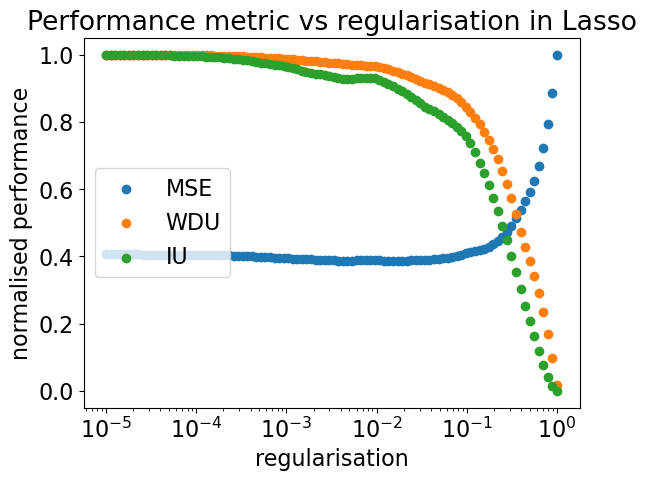

In [67]:
for m in ["MSE", "WDU", "IU"]:
    plt.scatter(lasso_results_train["alphas"], lasso_results_val[m] / max(lasso_results_val[m]), label=m)
#plt.scatter(lasso_results_train["alphas"], lasso_results_train["Correlation"] / max(lasso_results_train["Correlation"]), label="Correlation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
#plt.yscale("log")
plt.title("Performance metric vs regularisation in Lasso")
plt.xlabel("regularisation")
plt.ylabel("normalised performance")
plt.xscale("log")
plt.legend(loc="center left")
plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_lasso_test.pdf")

In [68]:
X1_train = np.concatenate([np.ones(len(S_train)).reshape(-1,1), X_train], axis=1)
X1_test = np.concatenate([np.ones(len(S_test)).reshape(-1,1), X_test], axis=1)
w = lasso_results_train["CoeffPath"][10,:]
y_pred_test = X1_test @ w
y_pred_train = X1_train @ w
w

array([-7.07926509e-16,  1.09728992e+00, -9.42778920e-02,  5.95081090e-04,
       -9.32226533e-02, -4.58605403e-02,  1.61481117e-01, -9.39546650e-01,
        1.82365746e-01, -7.03878946e-01, -1.70699267e-01,  2.73014711e-02,
       -4.67219604e-01,  9.85057076e-02, -4.63422994e-02, -7.91881772e-02,
        6.31890462e-01, -2.08363403e-01, -3.60003822e-03, -2.60581990e-02,
       -3.64183390e-02,  4.10938326e-03,  8.03402025e-02,  9.85937517e-03,
        8.06321084e-03, -1.88441914e-01, -6.97361575e-02, -2.49735331e-02,
        9.09981160e-03, -4.97735605e-04,  2.51354805e-01, -1.15040474e-02,
       -2.41196117e-02, -7.51869624e-02,  1.90280540e-01,  3.95289574e-01,
        1.52750032e-01,  1.63824399e-01, -4.29973377e-01,  0.00000000e+00,
        1.96298390e-01, -8.46606051e-01,  2.92972435e-02,  5.29001153e-02,
        8.12174139e-02, -1.64910326e-01, -1.68862630e-01,  2.17482013e-01,
       -9.53585174e-02,  1.03972733e-01, -1.39379044e-01, -3.14826273e-02,
        9.75158808e-02, -

In [69]:
# r squared coeff

def r_squared(y_true, y_pred):

    # Residual Sum of Squares (SS_res)
    ss_res = np.sum((y_true - y_pred) ** 2)

    # Total Sum of Squares (SS_tot)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    # R-squared score
    r_squared = 1 - (ss_res / ss_tot)

    return r_squared
# # Residual Sum of Squares (SS_res)
# ss_res = np.sum((y_test - y_pred_test) ** 2)
#
# # Total Sum of Squares (SS_tot)
# ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
#
# # R-squared score
# r_squared = 1 - (ss_res / ss_tot)
print(f"R² Score (train): {r_squared(y_train, y_pred_train)}")
print(f"R² Score (test): {r_squared(y_test, y_pred_test)}")

R² Score (train): 0.6907932156445185
R² Score (test): 0.6041280050865754


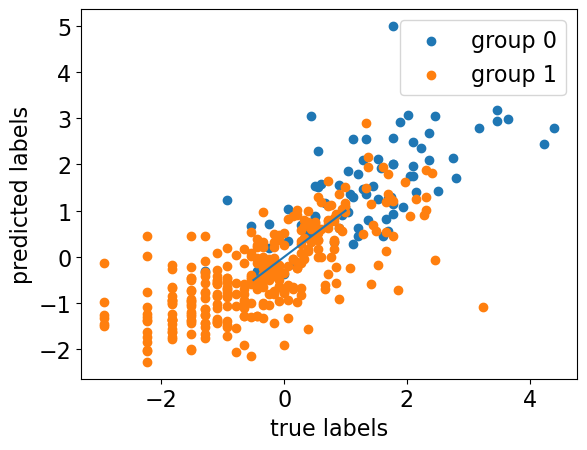

In [70]:
plt.scatter(y_test[S_test==0], y_pred_test[S_test==0],label="group 0")
plt.scatter(y_test[S_test==1], y_pred_test[S_test==1],label="group 1")
plt.plot(np.linspace(-0.5,1,100), np.linspace(-0.5,1,100))
plt.xlabel("true labels")
plt.ylabel("predicted labels")
plt.legend()

### Fair Lasso

In [ ]:
lamdas = np.abs(feature_selection.r_regression(X_train,S_train))
W = np.diag(1.0/lamdas)
X_star= X_train @ W
#alphas_fair_lasso, coeff_fair_lasso,_ = linear_model.lasso_path(X_star, y_train)
alphas_fair_lasso  = np.logspace(-3, 3, num=30, endpoint=True, base=10.0)
#alphas=np.linspace(0.01,30,200)
flasso = fairlasso()
flasso_results_train, flasso_results_val = flasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas_fair_lasso, metric='correlation', plot=False, coeff=2.0)

In [ ]:
for m in ["MSE", "WDU", "IU"]:
    plt.plot(flasso_results_train["budget"], flasso_results_train[m]/ max(flasso_results_train[m]), label=m, marker="o")

plt.title("Performance metric vs regularisation in FairLasso")
plt.xlabel("Unfairness")
plt.ylabel("normalised performance")
plt.xscale("log")
plt.legend()
plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_fairlasso.pdf")

In [73]:
# model size vs regularisation
# size_set = np.sum(flasso_results_train["CoeffPath"] != 0.0, axis=1)
# plt.plot(flasso_results_train["alphas"], size_set)
# plt.xscale("log")

In [74]:
def pareto_plot(m1,m2, fair_lasso_results, lasso_results, frrm_results = None, cald_results = None, fp_results = None, pp_results = None, sp_results = None, save_fig=None, normalise = False, legend = True):

    colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

    if normalise:
        max_1 = max( max(lasso_results[m1]), max(fair_lasso_results[m1]), max(frrm_results[m1]))
        max_2 = max( max(lasso_results[m2]), max(fair_lasso_results[m2]), max(frrm_results[m2]))
    else:
        max_1, max_2 = 1.0,1.0

    fig, ax = plt.subplots()
    ax.plot(  lasso_results[m1]/max_1, lasso_results[m2]/max_2, label="Lasso", marker = "o", color="k")

    ax.plot( fair_lasso_results[m1]/max_1,  fair_lasso_results[m2]/max_2, label="Fair Lasso", marker = "o", color='tab:blue')

    if cald_results is not None:
        ax.plot(  cald_results[m1]/max_1, cald_results[m2]/max_2, label="MD", marker = "o", color="tab:orange")

    if frrm_results is not None:
        ax.plot( frrm_results[m1]/max_1,  frrm_results[m2]/max_2, label="FRRM", marker = "v", color="tab:red")

    if fp_results is not None:
        avg_1 = np.mean(fp_results[m1], axis=1)
        avg_2 = np.mean(fp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="PP", marker="v", color='tab:brown')

    if pp_results is not None:
        avg_1 = np.mean(pp_results[m1], axis=1)
        avg_2 = np.mean(pp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="FP", marker = "P", color='tab:green')

    if sp_results is not None:
        avg_1 = np.mean(sp_results[m1], axis=1)
        avg_2 = np.mean(sp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="SP", marker = "v", color="k")

    #plt.yscale("log")
    plt.xlabel(m1)
    plt.ylabel(m2)
    if legend:
        plt.legend(loc="best")
    if save_fig is not None:
        plt.tight_layout()
        plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/" + save_fig)

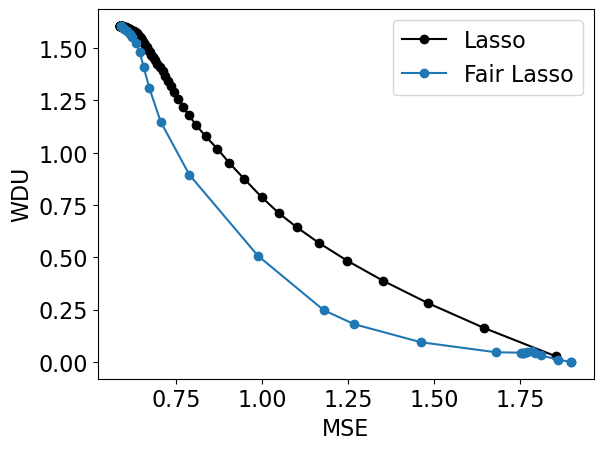

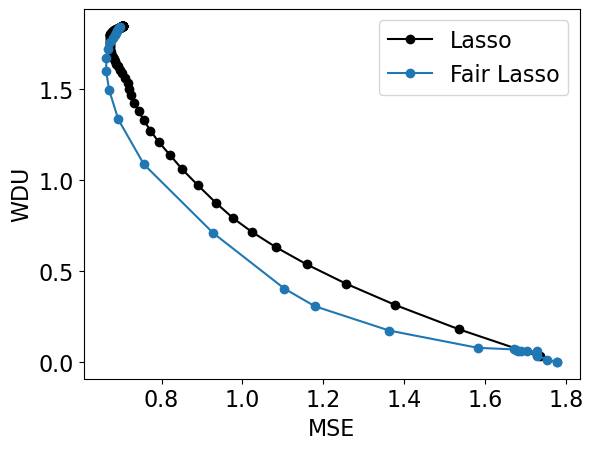

In [75]:
m2,m1 = "WDU", "MSE"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train) # save_fig="regression_comp_train_1")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val) # save_fig="regression_comp_test_1")

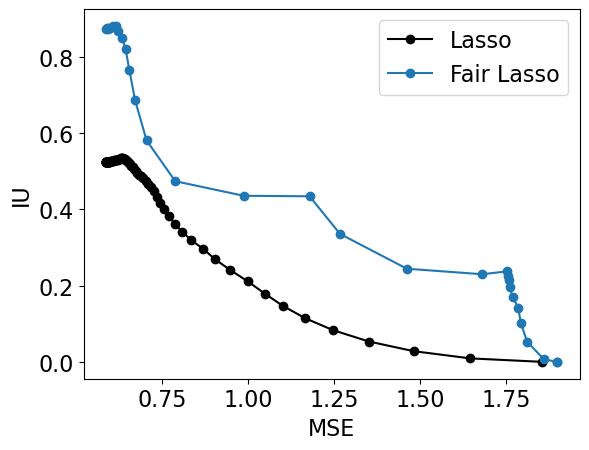

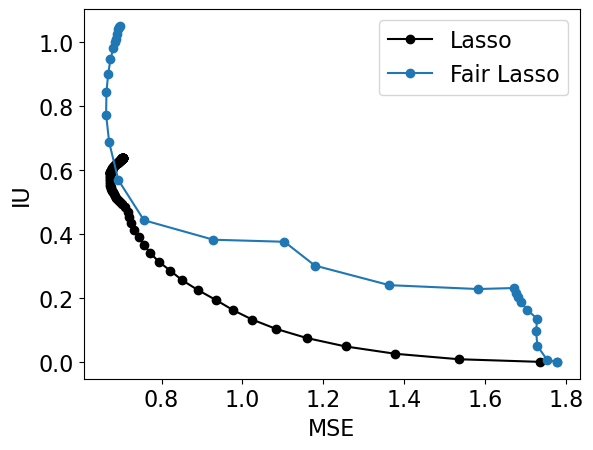

In [76]:
m2,m1 = "IU", "MSE"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train) # save_fig="regression_comp_train_1")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val)

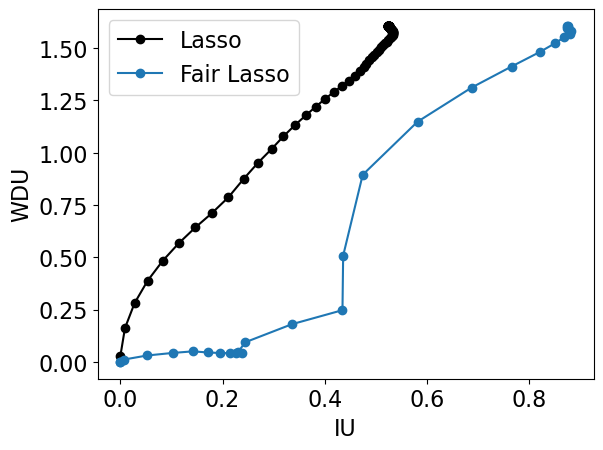

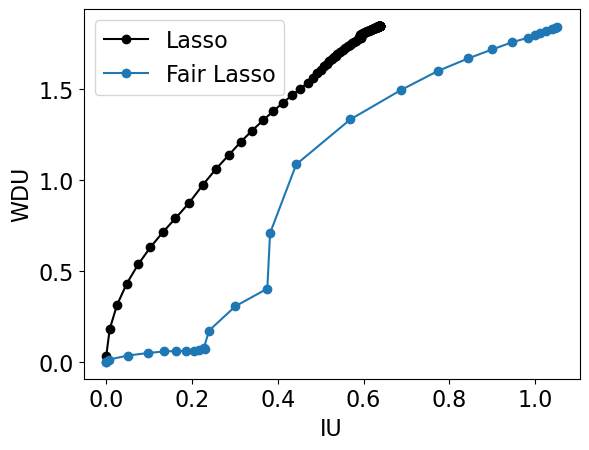

In [77]:
m2,m1 = "WDU", "IU"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train) # save_fig="regression_comp_train_1")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val)

### FRRM

In [78]:
budget = np.logspace(-7, 0, num=100, endpoint=True, base=10.0)
budget[-1]

1.0

In [79]:
frrm_train, frrm_val = evaluate_frrm( X_train,  y_train, S_train, X_test, y_test, S_test, budget=budget, metric="correlation", coeff=2.0, task = "reg")

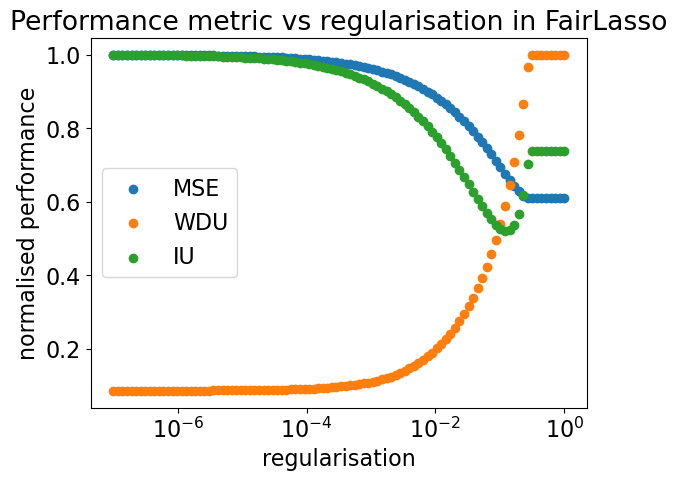

In [80]:
for m in ["MSE", "WDU", "IU"]:
    plt.scatter(frrm_train["budget"], frrm_train[m]/ max(frrm_train[m]), label=m)
# plt.scatter(results_train["alphas"], results_train["mse"]/ max(results_train["mse"]), label="MSE")
# plt.scatter(results_train["alphas"], results_train["WDunfair"] /  max(results_train["WDunfair"]), label="DP-WD")
# plt.scatter(results_train["alphas"], results_train["Indiv"] / max(results_train["Indiv"]), label="Indiv")
#plt.scatter(results_train["alphas"], results_train["Correlation"], label="Correlation")
#plt.scatter(results_train["alphas"], results_train["Pen"], label="Penalisation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
plt.title("Performance metric vs regularisation in FairLasso")
plt.xlabel("regularisation")
plt.ylabel("normalised performance")
plt.xscale("log")
plt.legend()
#plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_frrm.pdf")

### Calders

In [81]:
alphas  = np.logspace(-0.5, 5, num=100, endpoint=True, base=10.0)
#alphas=np.linspace(0.001,10000,50)
cald_results_train, cald_results_val = evaluate_calders(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas, coeff=2.0)

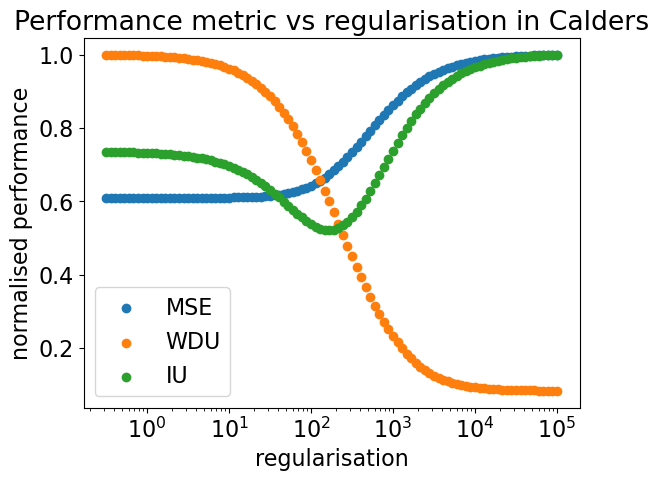

In [82]:
for m in ["MSE", "WDU", "IU"]:
    plt.scatter(cald_results_train["alphas"], cald_results_train[m]/ max(cald_results_train[m]), label=m)
# plt.scatter(results_train["alphas"], results_train["mse"]/ max(results_train["mse"]), label="MSE")
# plt.scatter(results_train["alphas"], results_train["WDunfair"] /  max(results_train["WDunfair"]), label="DP-WD")
# plt.scatter(results_train["alphas"], results_train["Indiv"] / max(results_train["Indiv"]), label="Indiv")
#plt.scatter(results_train["alphas"], results_train["Correlation"], label="Correlation")
#plt.scatter(results_train["alphas"], results_train["Pen"], label="Penalisation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
plt.title("Performance metric vs regularisation in Calders")
plt.xlabel("regularisation")
plt.ylabel("normalised performance")
plt.xscale("log")
plt.legend()
#plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_calders.pdf")

## Comparison

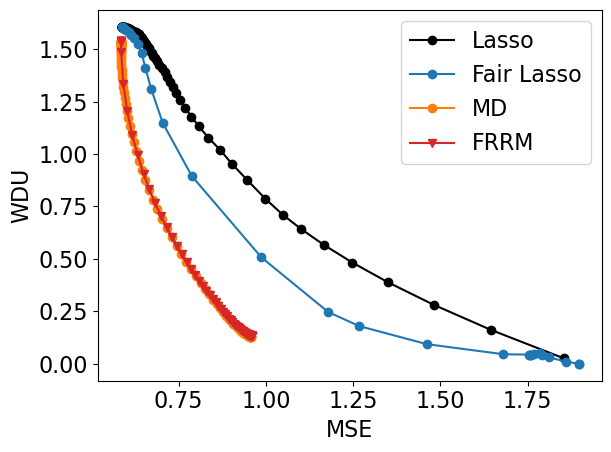

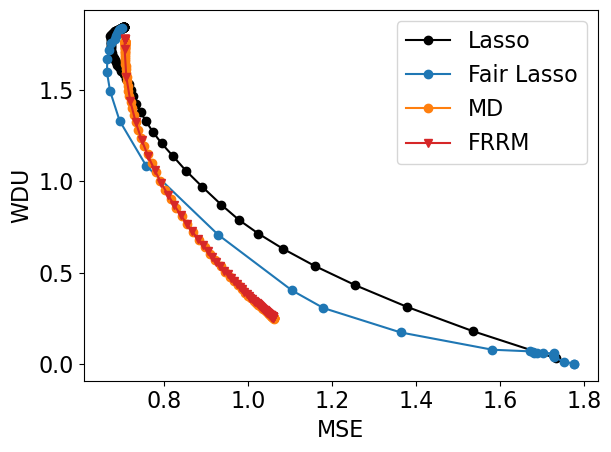

In [83]:
m2,m1 = "WDU", "MSE"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train, frrm_train, cald_results_train, save_fig="community_comp_train_1")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val, frrm_val, cald_results_val, save_fig="community_comp_test_1")

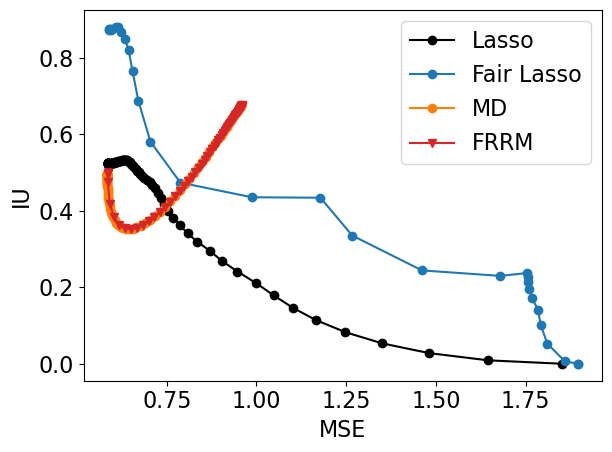

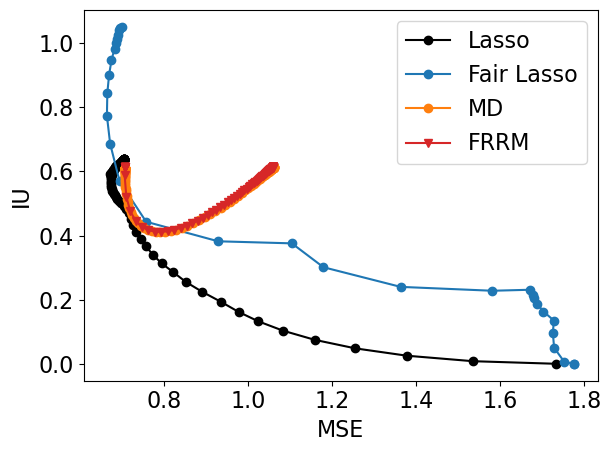

In [84]:
m2,m1 = "IU", "MSE"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train, frrm_train, cald_results_train, save_fig="community_comp_train_2")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val, frrm_val, cald_results_val, save_fig="community_comp_test_2")

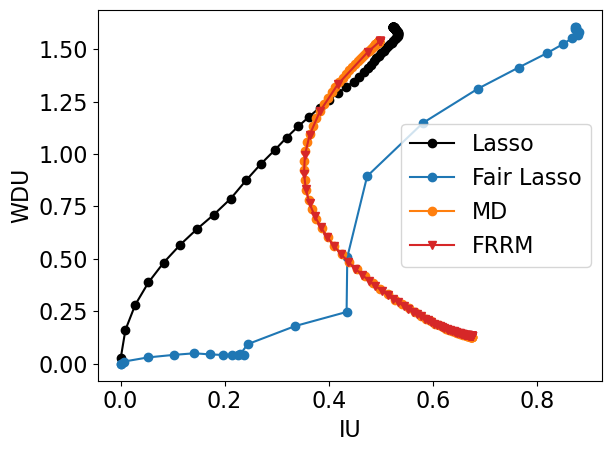

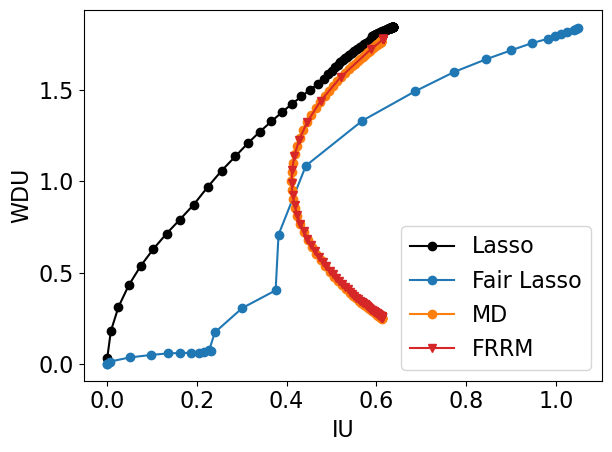

In [85]:
m2,m1 = "WDU", "IU"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train, frrm_train, cald_results_train, save_fig="community_comp_train_3")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val, frrm_val, cald_results_val, save_fig="community_comp_test_3")

In [86]:
def safe_min(arr):
    return np.min(arr) if len(arr) > 0 else np.nan

def safe_argmin(arr):
    return np.argmin(arr) if len(arr) > 0 else np.nan

{'Lasso': {'MSE': [1.7346350206050758, 1.7346350206050758, 1.2550965469747488]}, 'Fair Lasso': {'MSE': [1.7259599290159284, 1.581741752438325, 1.103766182953616]}, 'FRRM': {'MSE': [nan, nan, 0.9508339760548047]}, 'MD': {'MSE': [nan, nan, 0.9561460180316822]}}


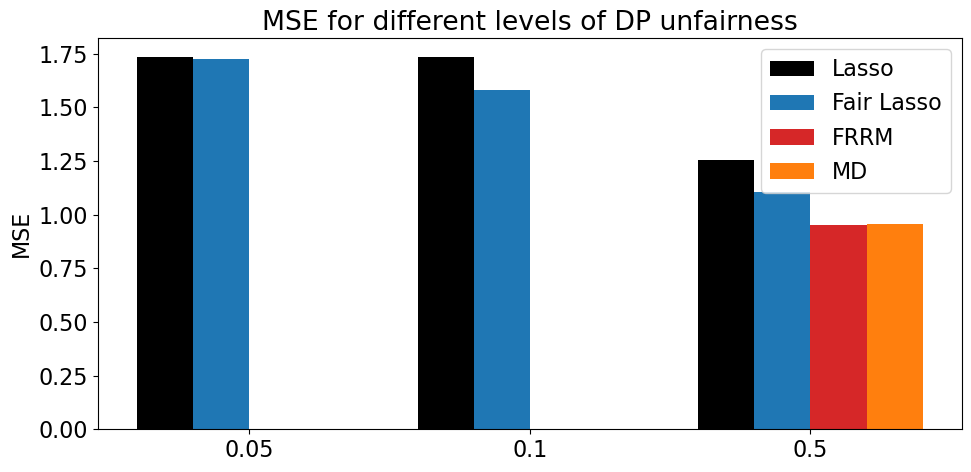

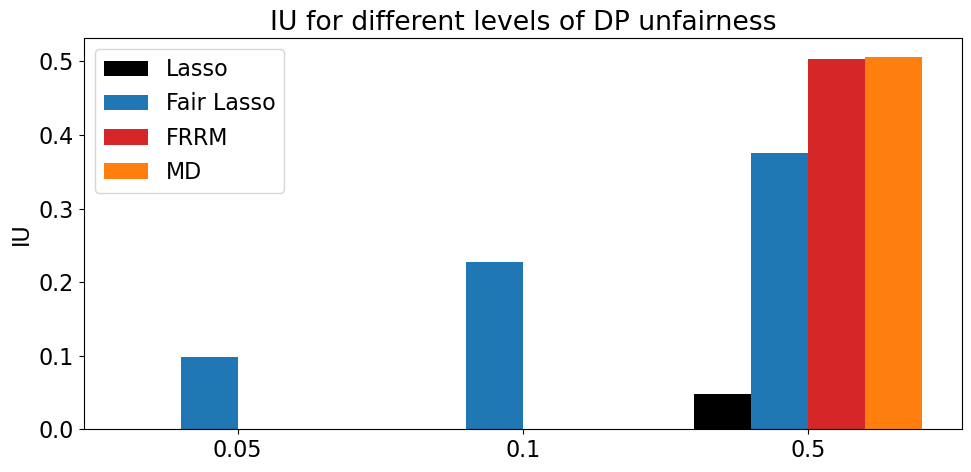

In [87]:
# levels of unfairness
l1 = 0.05
l2 = 0.1
l3 = 0.5


comp = {"Lasso" : {}, "Fair Lasso" : {}, "FRRM": {}, "MD": {}}

idx_lasso = [np.argmin(lasso_results_val["MSE"][lasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_flasso = [np.argmin(flasso_results_val["MSE"][flasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_frrm = [safe_argmin(frrm_val["MSE"][frrm_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_cald = [safe_argmin(cald_results_val["MSE"][cald_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]

#print(idx_lasso)

comp["Lasso"]["MSE"] = [ np.min(lasso_results_val["MSE"][lasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["Fair Lasso"]["MSE"] = [ np.min(flasso_results_val["MSE"][flasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["FRRM"]["MSE"] = [ safe_min(frrm_val["MSE"][frrm_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["MD"]["MSE"] = [ safe_min(cald_results_val["MSE"][cald_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
print(comp)

comp["Lasso"]["IU"] = [lasso_results_val["IU"][lasso_results_val["WDU"] <= l][idx_lasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["Fair Lasso"]["IU"] = [ flasso_results_val["IU"][flasso_results_val["WDU"] <= l][idx_flasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FRRM"]["IU"] = [ frrm_val["IU"][frrm_val["WDU"] <= l][idx_frrm[i]] if idx_frrm[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3])]
comp["MD"]["IU"] = [ cald_results_val["IU"][cald_results_val["WDU"] <= l][idx_cald[i]] if idx_cald[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3]) ]

for m in ["MSE", "IU"]:

    fig, ax = plt.subplots(figsize=(10, 5))

    methods = list(comp.keys())
    n_methods = len(methods)
    n_metrics = len(comp["Lasso"][m])

    colors=["k", "tab:blue", "tab:red", "tab:orange"]
    #colors = plt.cm.tab10.colors

    x = np.arange(n_metrics)
    width = 0.8 / n_methods

    for i, method in enumerate(list(comp.keys())):
        offset = (i - n_methods / 2 + 0.5) * width
        ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([l1,l2,l3])
    ax.set_ylabel(m)
    ax.set_title(f'{m} for different levels of DP unfairness')
    ax.legend()
    #ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_3budgets_WDU_{m}.pdf")

[nan, nan, nan] [nan, nan, nan]
{'Lasso': {'MSE': [1.3782378165476028, 1.2550965469747488, 1.1585376258365199]}, 'Fair Lasso': {'MSE': [1.7530683179953896, 1.7530683179953896, 1.7259599290159284]}, 'FRRM': {'MSE': [nan, nan, nan]}, 'MD': {'MSE': [nan, nan, nan]}}


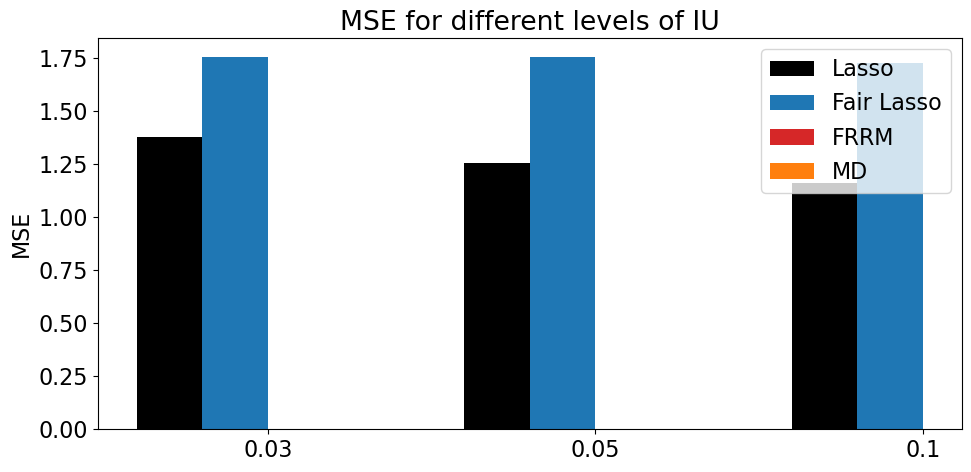

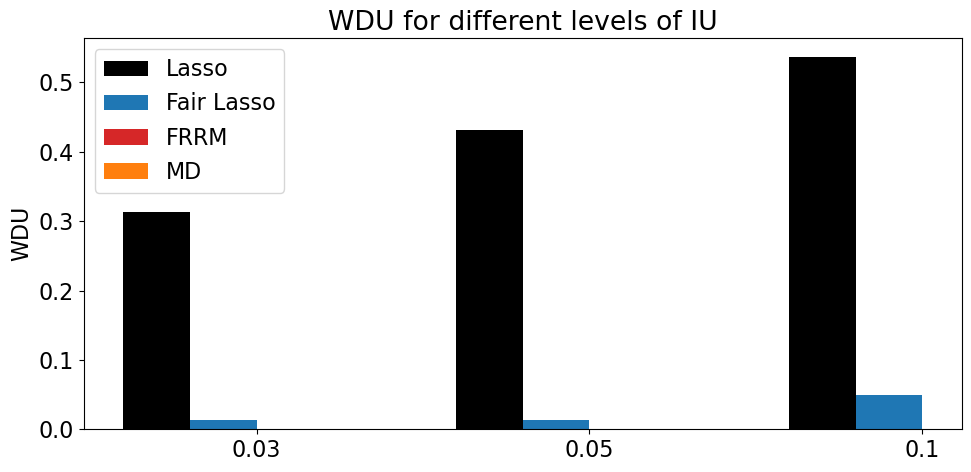

In [88]:
# levels of unfairness
l1 = 0.03
l2 = 0.05
l3 = 0.1


comp = {"Lasso" : {}, "Fair Lasso" : {}, "FRRM": {}, "MD": {}}

idx_lasso = [np.argmin(lasso_results_val["MSE"][lasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_flasso = [np.argmin(flasso_results_val["MSE"][flasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_frrm = [safe_argmin(frrm_train["MSE"][frrm_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_cald = [safe_argmin(cald_results_val["MSE"][cald_results_val["IU"] <= l]) for l in [l1,l2,l3] ]

print(idx_frrm, idx_cald)

comp["Lasso"]["MSE"] = [ np.min(lasso_results_val["MSE"][lasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["Fair Lasso"]["MSE"] = [ np.min(flasso_results_val["MSE"][flasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["FRRM"]["MSE"] = [ safe_min(frrm_val["MSE"][frrm_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["MD"]["MSE"] = [ safe_min(cald_results_val["MSE"][cald_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
print(comp)

comp["Lasso"]["WDU"] = [lasso_results_val["WDU"][lasso_results_val["IU"] <= l][idx_lasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["Fair Lasso"]["WDU"] = [ flasso_results_val["WDU"][flasso_results_val["IU"] <= l][idx_flasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FRRM"]["WDU"] = [ frrm_val["WDU"][frrm_val["IU"] <= l][idx_frrm[i]] if idx_frrm[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3])]
comp["MD"]["WDU"] = [ cald_results_val["WDU"][cald_results_val["IU"] <= l][idx_cald[i]] if idx_cald[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3]) ]

for m in ["MSE", "WDU"]:
    fig, ax = plt.subplots(figsize=(10, 5))

    methods = list(comp.keys())
    n_methods = len(methods)
    n_metrics = len(comp["Lasso"][m])

    colors=["k", "tab:blue", "tab:red", "tab:orange"]
    #colors = plt.cm.tab10.colors

    x = np.arange(n_metrics)
    width = 0.8 / n_methods

    for i, method in enumerate(list(comp.keys())):
        offset = (i - n_methods / 2 + 0.5) * width
        ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([l1,l2,l3])
    ax.set_ylabel(m)
    ax.set_title(f'{m} for different levels of IU')
    ax.legend()
    #ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_3budgets_IU_{m}.pdf")

### Fair posteriors: projected posterior and posterior with l1-ball prior

In [89]:
y_train.T @ y_train

2944.9967257844078

In [116]:
a, b = 1, 1 # hyperparameter of gamma prior
phi = 1.0
alphas  = np.logspace(-3, 1.5, num=30, endpoint=True, base=10.0)
projection_post, conjugate_post = sample_projection_posterior(X_train, y_train.reshape(-1,1), S_train, a=a, b=b, beta_var=1.0, radius=alphas, intercept=True, num_samples = 1000, task="reg")

In [109]:
projection_post["samples"].shape

(30, 1000, 119)

In [110]:
np.mean(conjugate_post["samples var"])

0.6699249697093537

In [111]:
#y_train = y_train.to_numpy()
#y_test = y_test.to_numpy()

In [117]:
fp_results_train, fp_results_test = evaluate_posterior_per_budget(projection_post, X_train, S_train, y_train, X_test, S_test, y_test, intercept=True, coeff=2.0, task = "reg")
cp_results_train, cp_results_test = evaluate_conjugate_posterior(conjugate_post, X_train, S_train, y_train, X_test, S_test, y_test, weights=projection_post["weights"], intercept=True, coeff=2.0, task = "reg")

In [ ]:
proj_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=1.0, b=1.0, beta_var=1.0, radius=alphas, intercept=True, num_samples = 1000, task = "reg")

sample:  79%|███████▉  | 1576/2000 [01:10<00:13, 30.73it/s, 255 steps of size 1.39e-02. acc. prob=0.81]

In [ ]:
proj_prior["samples"].shape

In [ ]:
pp_results_train,pp_results_test = evaluate_posterior_per_budget(proj_prior, X_train, S_train, y_train, X_test, S_test, y_test, intercept=True, coeff=2.0, task = "reg")

In [ ]:
sparse_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=1.0, radius=alphas, intercept=True, num_samples = 1000, task = "reg", metric = None)

In [ ]:
sp_results_train,sp_results_test = evaluate_posterior_per_budget(sparse_prior, X_train, S_train, y_train, X_test, S_test, y_test, task = "reg", coeff = 2.0)

In [100]:
def posterior_risk_plot(fp_results, cp_results = None, savefig = None):

    colors = ["C0", "C1", "C2"]

    plt.figure(figsize=(8, 5))

    for i,m in enumerate(["MSE","WDU","IU"]):

        lower = np.percentile(fp_results[m], 2.5, axis=1)
        upper = np.percentile(fp_results[m], 97.5, axis=1)
        median = np.percentile(fp_results[m], 50, axis=1)
        avg = np.mean(fp_results[m], axis=1)

        cp_mean_value = np.max(fp_results[m])  #, np.max(cp_results[m]))
        #cp_mean_value = 1.0
        #cp_mean_value = cp_results_train["pmean"][i]

        plt.fill_between(
            fp_results["budget"],
            lower / cp_mean_value,
            upper / cp_mean_value,
            alpha=0.3,
            color=colors[i]
        )

        plt.plot(fp_results["budget"], avg / cp_mean_value, label=m, linewidth=2, color=colors[i])

        if cp_results is not None:
            lower = np.percentile(cp_results[m], 2.5)
            upper = np.percentile(cp_results[m], 97.5)
            plt.fill_between(
                fp_results["budget"],
                lower  / cp_mean_value * np.ones(len(fp_results["budget"])),
                upper / cp_mean_value * np.ones(len(fp_results["budget"])),
                alpha=0.2,
                color=colors[i]
            )
            plt.hlines(y= np.mean(cp_results[m]) / cp_mean_value, xmin=0.00, xmax=max(fp_results["budget"]), linestyles="dotted", color=colors[i])

    plt.xlabel("Unfairness budget")
    plt.ylabel("Metric")
    plt.xscale("log")
    plt.legend()
    if savefig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairModelSelection/figures/" + savefig)

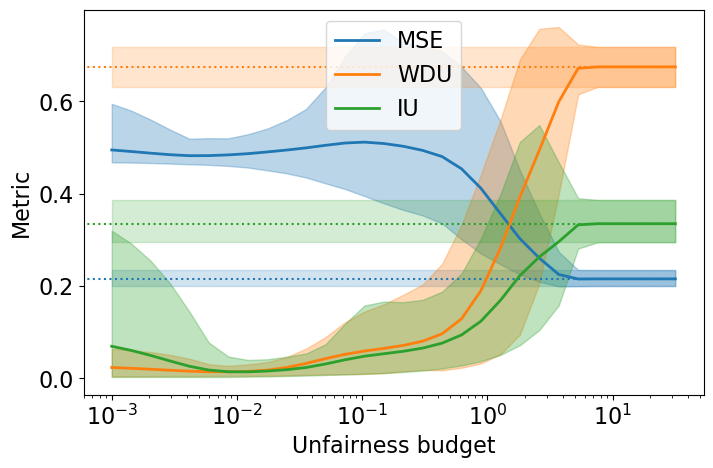

In [118]:
#posterior_risk_plot(fp_r   esults_train, cp_results_train) #, savefig = "community_pp_train")
posterior_risk_plot(fp_results_test, cp_results_test) #, savefig = "community_pp_test")

In [ ]:
 #posterior_risk_plot(pp_results_train, cp_results_train) #, savefig = "community_ppp_train")
posterior_risk_plot(pp_results_test, cp_results_test) #, savefig = "community_ppp_test")

In [ ]:
#posterior_risk_plot(sp_results_train, cp_results_train, savefig = "community_sp_train")
posterior_risk_plot(sp_results_test, cp_results_test) # savefig = "community_sp_test")

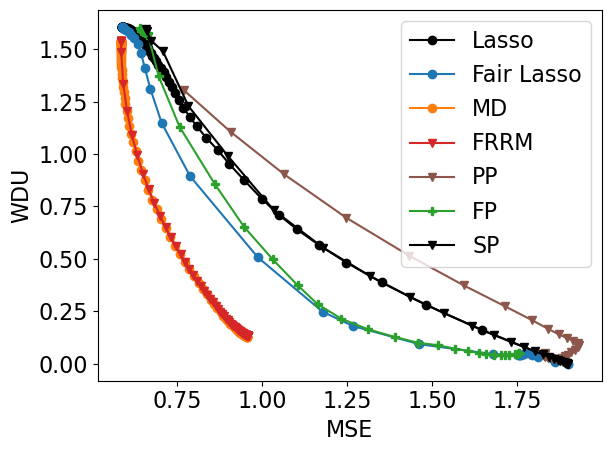

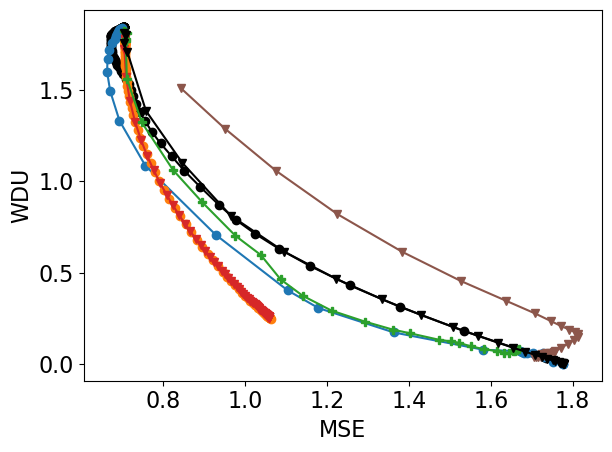

In [104]:
m2,m1 = "WDU", "MSE"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train, frrm_train, cald_results_train, fp_results=fp_results_train, pp_results=pp_results_train, sp_results=sp_results_train,
             save_fig="community_comp_all_train_1")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val, frrm_val, cald_results_val, fp_results=fp_results_test, pp_results=pp_results_test, sp_results=sp_results_test,
save_fig="community_comp_all_test_1", legend=False)

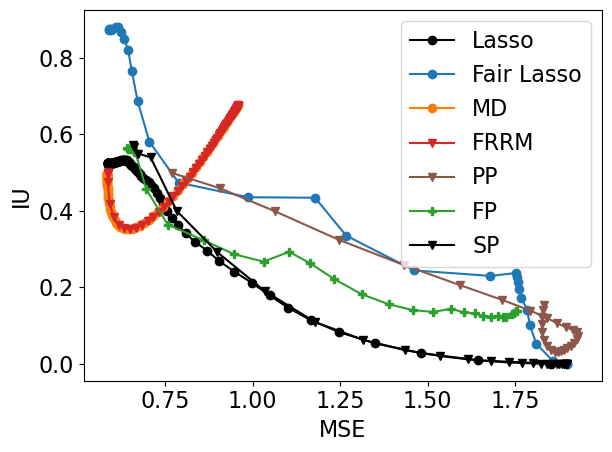

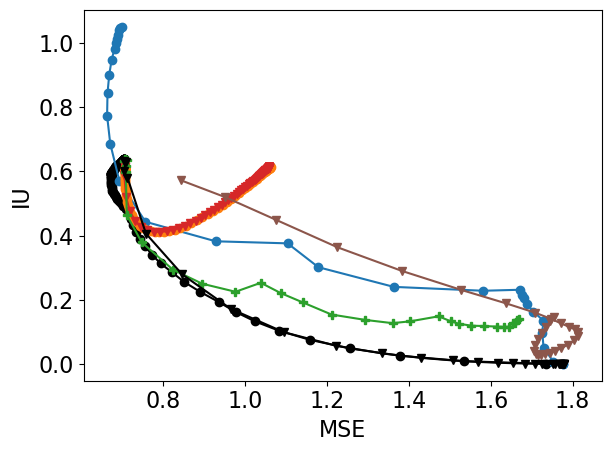

In [105]:
m2,m1 = "IU", "MSE"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train, frrm_train, cald_results_train, fp_results=fp_results_train, pp_results=pp_results_train,  sp_results=sp_results_train,
             save_fig="community_comp_all_train_2")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val, frrm_val, cald_results_val, fp_results=fp_results_test, pp_results=pp_results_test,  sp_results=sp_results_test,
             save_fig="community_comp_all_test_2", legend=False)

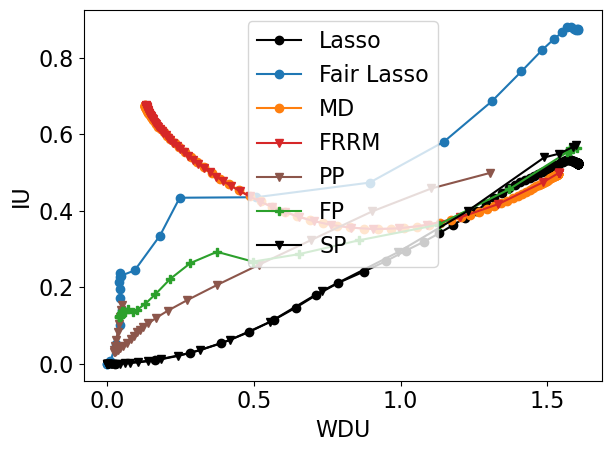

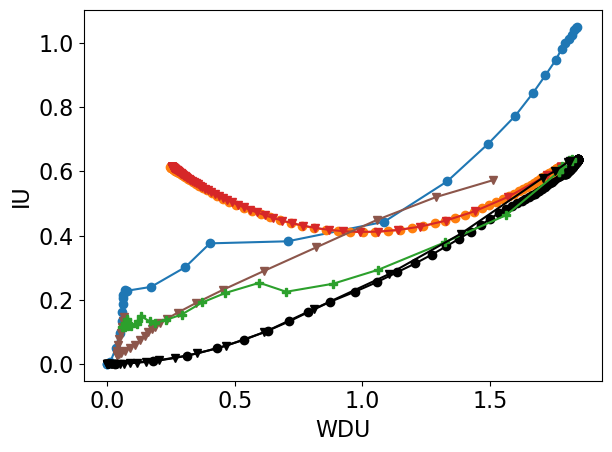

In [106]:
m1,m2 = "WDU", "IU"
pareto_plot(m1,m2, flasso_results_train, lasso_results_train, frrm_train, cald_results_train, fp_results=fp_results_train, pp_results=pp_results_train,  sp_results=sp_results_train,
             save_fig="community_comp_all_train_3")
pareto_plot(m1,m2, flasso_results_val, lasso_results_val, frrm_val, cald_results_val, fp_results=fp_results_test, pp_results=pp_results_test,  sp_results=sp_results_test,
            save_fig="community_comp_all_test_3", legend=False)

In [107]:
# levels of unfairness
l1 = 0.05
l2 = 0.1
l3 = 0.5

comp = {  "PP": {},  "FP" : {}, "Fair Lasso" : {}, "SP":{}, "Lasso" : {}, "FRRM": {}, "MD": {} }

# projected posterior
fp_avg_wdu =  np.median(fp_results_test["WDU"], axis=1)
fp_avg_mse =  np.median(fp_results_test["MSE"], axis=1)
fp_avg_iu =  np.median(fp_results_test["IU"], axis=1)

# projected prior
pp_avg_wdu =  np.median(pp_results_test["WDU"], axis=1)
pp_avg_mse =  np.median(pp_results_test["MSE"], axis=1)
pp_avg_iu =  np.median(pp_results_test["IU"], axis=1)

# sparse posterior
sp_avg_wdu =  np.median(sp_results_test["WDU"], axis=1)
sp_avg_mse =  np.median(sp_results_test["MSE"], axis=1)
sp_avg_iu =  np.median(sp_results_test["IU"], axis=1)


idx_lasso = [np.argmin(lasso_results_val["MSE"][lasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_flasso = [np.argmin(flasso_results_val["MSE"][flasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_frrm = [safe_argmin(frrm_val["MSE"][frrm_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_cald = [safe_argmin(cald_results_val["MSE"][cald_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_pp = [np.argmin(fp_avg_mse[fp_avg_wdu <= l]) for l in [l1,l2,l3] ]
idx_ppp = [np.argmin(pp_avg_mse[pp_avg_wdu <= l]) for l in [l1,l2,l3] ]
idx_sp = [np.argmin(sp_avg_mse[sp_avg_wdu <= l]) for l in [l1,l2,l3] ]

#print(idx_lasso)

err = {"PP": {}, "FP":{}, "SP":{}}
err["PP"]["MSE"] = np.transpose([ [np.percentile(fp_results_test["MSE"][i], 5), np.percentile(fp_results_test["MSE"][i], 95)] for i in idx_pp])
err["PP"]["IU"]= np.transpose([ [np.percentile(fp_results_test["IU"][i], 5), np.percentile(fp_results_test["IU"][i], 95)] for i in idx_pp])
err["FP"]["MSE"] = np.transpose([ [np.percentile(pp_results_test["MSE"][i], 5), np.percentile(pp_results_test["MSE"][i], 95)] for i in idx_ppp])
err["FP"]["IU"]= np.transpose([ [np.percentile(pp_results_test["IU"][i], 5), np.percentile(pp_results_test["IU"][i], 95)] for i in idx_ppp])
err["SP"]["MSE"] = np.transpose([ [np.percentile(sp_results_test["MSE"][i], 5), np.percentile(sp_results_test["MSE"][i], 95)] for i in idx_ppp])
err["SP"]["IU"]= np.transpose([ [np.percentile(sp_results_test["IU"][i], 5), np.percentile(sp_results_test["IU"][i], 95)] for i in idx_ppp])


comp["Lasso"]["MSE"] = [ np.min(lasso_results_val["MSE"][lasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["Fair Lasso"]["MSE"] = [ np.min(flasso_results_val["MSE"][flasso_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["FRRM"]["MSE"] = [ safe_min(frrm_val["MSE"][frrm_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["MD"]["MSE"] = [ safe_min(cald_results_val["MSE"][cald_results_val["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["PP"]["MSE"] = [ np.min(fp_avg_mse[fp_avg_wdu <= l]) for l in [l1,l2,l3] ]
comp["FP"]["MSE"] = [ np.min(pp_avg_mse[pp_avg_wdu <= l]) for l in [l1,l2,l3] ]
comp["SP"]["MSE"] = [ np.min(sp_avg_mse[sp_avg_wdu <= l]) for l in [l1,l2,l3] ]


print(comp)

comp["Lasso"]["IU"] = [lasso_results_val["IU"][lasso_results_val["WDU"] <= l][idx_lasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["Fair Lasso"]["IU"] = [ flasso_results_val["IU"][flasso_results_val["WDU"] <= l][idx_flasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FRRM"]["IU"] = [ frrm_val["IU"][frrm_val["WDU"] <= l][idx_frrm[i]] if idx_frrm[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3])]
comp["MD"]["IU"] = [ cald_results_val["IU"][cald_results_val["WDU"] <= l][idx_cald[i]] if idx_cald[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3]) ]
comp["PP"]["IU"] = [fp_avg_iu[fp_avg_wdu <= l][idx_pp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FP"]["IU"] = [pp_avg_iu[pp_avg_wdu <= l][idx_ppp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["SP"]["IU"] = [sp_avg_iu[sp_avg_wdu <= l][idx_sp[i]] for i,l in enumerate([l1,l2,l3]) ]


for m in ["MSE", "IU"]:
    fig, ax = plt.subplots(figsize=(12, 5))

    methods = list(comp.keys())
    n_methods = len(methods)
    n_metrics = len(comp["Lasso"][m])

    colors=["tab:brown",  "tab:green",  "tab:blue", "tab:grey", "k", "tab:red", "tab:orange"]
    #colors = plt.cm.tab10.colors

    x = np.arange(n_metrics)
    width = 0.8 / n_methods

    for i, method in enumerate(list(comp.keys())):
        offset = (i - n_methods / 2 + 0.5) * width
        # if method in ["PPP", "PP", "SP"]:
        #     ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i], yerr = err[method][m])
        # else:
        if method != "PP":
            ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([l1,l2,l3])
    ax.set_ylabel(m)
    ax.set_title(f'{m} for different levels of DP unfairness')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    #ax.set_ylim(0, 1)
    plt.xlabel("WDU")

    plt.tight_layout()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_3budgets_WDU_{m}.pdf")

ValueError: attempt to get argmin of an empty sequence

In [ ]:
# levels of unfairness
l1 = 0.02
l2 = 0.04
l3 = 0.08

comp = { "PP" : {}, "FP": {},  "Fair Lasso" : {},"SP":{},  "Lasso" : {}, "FRRM": {}, "MD": {} }

# projected posterior
fp_avg_wdu =  np.median(fp_results_test["WDU"], axis=1)
fp_avg_mse =  np.median(fp_results_test["MSE"], axis=1)
fp_avg_iu =  np.median(fp_results_test["IU"], axis=1)

# projected prior
pp_avg_wdu =  np.median(pp_results_test["WDU"], axis=1)
pp_avg_mse =  np.median(pp_results_test["MSE"], axis=1)
pp_avg_iu =  np.median(pp_results_test["IU"], axis=1)

# sparse posterior
sp_avg_wdu =  np.median(sp_results_test["WDU"], axis=1)
sp_avg_mse =  np.median(sp_results_test["MSE"], axis=1)
sp_avg_iu =  np.median(sp_results_test["IU"], axis=1)


idx_lasso = [np.argmin(lasso_results_val["MSE"][lasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_flasso = [np.argmin(flasso_results_val["MSE"][flasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_frrm = [safe_argmin(frrm_val["MSE"][frrm_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_cald = [safe_argmin(cald_results_val["MSE"][cald_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
idx_pp = [np.argmin(fp_avg_mse[fp_avg_iu <= l]) for l in [l1,l2,l3] ]
idx_ppp = [np.argmin(pp_avg_mse[pp_avg_iu <= l]) for l in [l1,l2,l3] ]
idx_sp = [np.argmin(sp_avg_mse[sp_avg_iu <= l]) for l in [l1,l2,l3] ]

#print(idx_lasso)

err = {"PP": {}, "FP":{}, "SP":{}}
err["PP"]["MSE"] = np.transpose([ [np.percentile(fp_results_test["MSE"][i], 5), np.percentile(fp_results_test["MSE"][i], 95)] for i in idx_pp])
err["PP"]["IU"]= np.transpose([ [np.percentile(fp_results_test["IU"][i], 5), np.percentile(fp_results_test["IU"][i], 95)] for i in idx_pp])
err["FP"]["MSE"] = np.transpose([ [np.percentile(pp_results_test["MSE"][i], 5), np.percentile(pp_results_test["MSE"][i], 95)] for i in idx_ppp])
err["FP"]["IU"]= np.transpose([ [np.percentile(pp_results_test["IU"][i], 5), np.percentile(pp_results_test["IU"][i], 95)] for i in idx_ppp])
err["SP"]["MSE"] = np.transpose([ [np.percentile(sp_results_test["MSE"][i], 5), np.percentile(sp_results_test["MSE"][i], 95)] for i in idx_ppp])
err["SP"]["IU"]= np.transpose([ [np.percentile(sp_results_test["IU"][i], 5), np.percentile(sp_results_test["IU"][i], 95)] for i in idx_ppp])


comp["Lasso"]["MSE"] = [ np.min(lasso_results_val["MSE"][lasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["Fair Lasso"]["MSE"] = [ np.min(flasso_results_val["MSE"][flasso_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["FRRM"]["MSE"] = [ safe_min(frrm_val["MSE"][frrm_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["MD"]["MSE"] = [ safe_min(cald_results_val["MSE"][cald_results_val["IU"] <= l]) for l in [l1,l2,l3] ]
comp["PP"]["MSE"] = [ np.min(fp_avg_mse[fp_avg_iu <= l]) for l in [l1,l2,l3] ]
comp["FP"]["MSE"] = [ np.min(pp_avg_mse[pp_avg_iu <= l]) for l in [l1,l2,l3] ]
comp["SP"]["MSE"] = [ np.min(sp_avg_mse[sp_avg_iu <= l]) for l in [l1,l2,l3] ]


#print(comp)

comp["Lasso"]["WDU"] = [lasso_results_val["WDU"][lasso_results_val["IU"] <= l][idx_lasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["Fair Lasso"]["WDU"] = [ flasso_results_val["WDU"][flasso_results_val["IU"] <= l][idx_flasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FRRM"]["WDU"] = [ frrm_val["WDU"][frrm_val["IU"] <= l][idx_frrm[i]] if idx_frrm[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3])]
comp["MD"]["WDU"] = [ cald_results_val["WDU"][cald_results_val["IU"] <= l][idx_cald[i]] if idx_cald[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3]) ]
comp["PP"]["WDU"] = [fp_avg_wdu[fp_avg_iu <= l][idx_pp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FP"]["WDU"] = [pp_avg_wdu[pp_avg_iu <= l][idx_ppp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["SP"]["WDU"] = [sp_avg_wdu[sp_avg_iu <= l][idx_sp[i]] for i,l in enumerate([l1,l2,l3]) ]


for m in ["MSE", "WDU"]:
    fig, ax = plt.subplots(figsize=(12, 5))

    methods = list(comp.keys())
    n_methods = len(methods)
    n_metrics = len(comp["Lasso"][m])

    colors=[ "tab:brown",  "tab:green", "tab:blue", "tab:grey", "k", "tab:red", "tab:orange"]
    #colors = plt.cm.tab10.colors

    x = np.arange(n_metrics)
    width = 0.8 / n_methods

    for i, method in enumerate(list(comp.keys())):
        offset = (i - n_methods / 2 + 0.5) * width
        # if method in ["PPP", "PP", "SP"]:
        #     ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i], yerr = err[method][m])
        # else:
        if method != "PP":
            ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([l1,l2,l3])
    ax.set_ylabel(m)
    ax.set_title(f'{m} for different levels of IU unfairness')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    #ax.set_ylim(0, 1)
    plt.xlabel("IU")

    plt.tight_layout()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairModelSelection/figures/community_data_3budgets_IU_{m}.pdf")